In [ ]:
!pip install lime

In [ ]:
!pip install alibi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of spacy[lookups] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.1/522.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 95.2 MB/s eta 0:00:00

In [ ]:
!pip install xgboost

In [ ]:
!pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
!pip install shap

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance
import interpret
import lime
import lime.lime_tabular
from alibi.explainers import ALE, plot_ale


In [ ]:
df = pd.read_csv("cardio_data_cleaned(IQR).csv")
df.head()

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,BMI,MAP
0,3,2,1,1,0,0,1,0,2,2
1,4,1,3,1,0,0,1,1,3,4
2,3,1,3,1,0,0,0,1,2,2
3,2,2,1,1,0,0,1,1,3,5
4,5,1,2,2,0,0,0,0,3,2


In [ ]:
X = df.drop('cardio',axis =1)
y = df['cardio']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training and Evaluation

## Individual Models

### Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42)
param_grid_lr = {
    'C': np.arange(1, 10, 1),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
}
random_search_lr = RandomizedSearchCV(lr, param_distributions=param_grid_lr, n_iter=10, cv=5, random_state=42)
random_search_lr.fit(X_train, y_train)
best_lr = random_search_lr.best_estimator_
print("Best parameters for Logistic Regression:", random_search_lr.best_params_)

Best parameters for Logistic Regression: {'solver': 'saga', 'penalty': 'l2', 'C': np.int64(9)}


In [ ]:
y_pred_lr = best_lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.7211423086153108
Precision: 0.7430808448652586
Recall: 0.6629304743339831
F1 Score: 0.7007211538461539
ROC AUC Score: 0.7202753238494186


### Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(1, 20, 1),
    'min_samples_split': np.arange(2, 20, 1),
    'min_samples_leaf': np.arange(1, 20, 1),
    'class_weight': [None, 'balanced'],
    'splitter': ['best', 'random'],
}
random_search_dt = RandomizedSearchCV(dt, param_distributions=param_grid_dt, n_iter=60, cv=5, random_state=42)
random_search_dt.fit(X_train, y_train)
best_dt = random_search_dt.best_estimator_
print("Best parameters for Decision Tree:", random_search_dt.best_params_)

Best parameters for Decision Tree: {'splitter': 'best', 'min_samples_split': np.int64(3), 'min_samples_leaf': np.int64(14), 'max_depth': np.int64(6), 'criterion': 'gini', 'class_weight': None}


In [ ]:
y_pred_dt = best_dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_dt))

Accuracy: 0.7241020718342532
Precision: 0.7421721238146359
Recall: 0.6738141650422352
F1 Score: 0.7063431247339294
ROC AUC Score: 0.7233531030096912


### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': np.arange(10, 200, 10),
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(1, 20, 1),
    'min_samples_split': np.arange(2, 20, 1),
    'min_samples_leaf': np.arange(1, 20, 1),
    'class_weight': [None, 'balanced'],
}
random_search_rf = RandomizedSearchCV(rf, param_distributions=param_grid_rf, n_iter=30, cv=3, random_state=42)
random_search_rf.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190])},
                   random_state=42)

In [ ]:
best_rf = random_search_rf.best_estimator_
print("Best parameters for Random Forest:", random_search_rf.best_params_)

Best parameters for Random Forest: {'n_estimators': np.int64(190), 'min_samples_split': np.int64(7), 'min_samples_leaf': np.int64(17), 'max_depth': np.int64(11), 'criterion': 'entropy', 'class_weight': None}


In [ ]:
y_pred_rf = random_search_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.7234621230301576
Precision: 0.7293897671256162
Recall: 0.697043534762833
F1 Score: 0.712849904477116
ROC AUC Score: 0.7230686546942613


### Naive Bayes

In [ ]:
nb = GaussianNB()
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=200)
}
random_search_nb = RandomizedSearchCV(nb, param_distributions=param_grid_nb, n_iter=40, cv=3, random_state=42)
random_search_nb.fit(X_train, y_train)
best_nb = random_search_nb.best_estimator_
print("Best parameters for Naive Bayes:", random_search_nb.best_params_)

Best parameters for Naive Bayes: {'var_smoothing': np.float64(0.04397603609302719)}


In [ ]:
y_pred_nb = best_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_nb))

Accuracy: 0.6990640748740101
Precision: 0.74609375
Recall: 0.5895061728395061
F1 Score: 0.6586206896551724
ROC AUC score: 0.6974323614394536


###  KNN

In [ ]:
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
random_search_knn = RandomizedSearchCV(knn, param_distributions=param_grid_knn, n_iter=10, cv=3, random_state=42)
random_search_knn.fit(X_train, y_train)
best_knn = random_search_knn.best_estimator_
print("Best parameters for KNN:", random_search_knn.best_params_)


Best parameters for KNN: {'weights': 'uniform', 'n_neighbors': np.int64(23), 'metric': 'euclidean'}


In [ ]:
y_pred_knn = best_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


Accuracy: 0.7153827693784497
Precision: 0.7201694915254238
Recall: 0.690220922677063
F1 Score: 0.7048772395487723


### Adaboost

In [ ]:
adb = AdaBoostClassifier()
param_grid_adb = {
    'n_estimators': np.arange(50, 201, 10),
    'learning_rate': np.logspace(-3, 0, num=10)
}
random_search_adb = RandomizedSearchCV(adb, param_distributions=param_grid_adb, n_iter=30, cv=3, random_state=42)
random_search_adb.fit(X_train, y_train)
best_adb = random_search_adb.best_estimator_
print("Best parameters for AdaBoost:", random_search_adb.best_params_)

Best parameters for AdaBoost: {'n_estimators': np.int64(120), 'learning_rate': np.float64(1.0)}


In [ ]:
y_pred_adb = best_adb.predict(X_test)
accuracy_adb = accuracy_score(y_test, y_pred_adb)
print("Accuracy:", accuracy_adb)
print("Precision:", precision_score(y_test, y_pred_adb))
print("Recall:", recall_score(y_test, y_pred_adb))
print("F1 Score:", f1_score(y_test, y_pred_adb))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_adb))

Accuracy: 0.7209823214142869
Precision: 0.7489734975737216
Recall: 0.6518843404808317
F1 Score: 0.6970644432864339
ROC AUC score: 0.7199532025493205


### XGBoost

In [ ]:
xgb = XGBClassifier()
param_grid_xgb = {
    'n_estimators': np.arange(50, 201, 10),
    'max_depth': np.arange(3, 16),
    'learning_rate': np.logspace(-3, 0, num=10),
    'subsample': np.linspace(0.5, 1.0, num=6),
    'colsample_bytree': np.linspace(0.5, 1.0, num=6)
}
random_search_xgb = RandomizedSearchCV(xgb, param_distributions=param_grid_xgb, n_iter=30, cv=3, random_state=42)
random_search_xgb.fit(X_train, y_train)
best_xgb = random_search_xgb.best_estimator_
print("Best parameters for XGBoost:", random_search_xgb.best_params_)

Best parameters for XGBoost: {'subsample': np.float64(0.6), 'n_estimators': np.int64(90), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.046415888336127774), 'colsample_bytree': np.float64(0.5)}


In [ ]:
y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_xgb))

Accuracy: 0.7257019438444925
Precision: 0.7365134431916739
Recall: 0.6897335932423652
F1 Score: 0.7123563459441322
ROC AUC score: 0.7251662450057373


### Stochastic Gradient Descent

In [ ]:
sdg = SGDClassifier(loss='log_loss')
param_grid_sdg = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': np.logspace(-4, 0, num=10),
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': np.logspace(-4, 0, num=10)
}
random_search_sdg = RandomizedSearchCV(sdg, param_distributions=param_grid_sdg, n_iter=50, cv=3, random_state=42)
random_search_sdg.fit(X_train, y_train)
best_sdg = random_search_sdg.best_estimator_
print("Best parameters for SGD:", random_search_sdg.best_params_)

Best parameters for SGD: {'penalty': 'elasticnet', 'learning_rate': 'constant', 'eta0': np.float64(0.000774263682681127), 'alpha': np.float64(0.0002782559402207126)}


In [ ]:
y_pred_sdg = best_lr.predict(X_test)
accuracy_sdg = accuracy_score(y_test, y_pred_sdg)
print("Accuracy:", accuracy_sdg)
print("Precision:", precision_score(y_test, y_pred_sdg))
print("Recall:", recall_score(y_test, y_pred_sdg))
print("F1 Score:", f1_score(y_test, y_pred_sdg))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_sdg))


Accuracy: 0.7211423086153108
Precision: 0.7430808448652586
Recall: 0.6629304743339831
F1 Score: 0.7007211538461539
ROC AUC score: 0.7202753238494186


### Quadratic Discriminant Analysis

In [ ]:
qda = QDA()
param_grid_qda = {
    'reg_param': np.linspace(0, 1, 50)
}
random_search_qda = RandomizedSearchCV(qda, param_distributions=param_grid_qda, n_iter=25, cv=5, random_state=42)
random_search_qda.fit(X_train, y_train)
best_qda = random_search_qda.best_estimator_
print("Best parameters for QDA:", random_search_qda.best_params_)

Best parameters for QDA: {'reg_param': np.float64(0.836734693877551)}


In [ ]:
y_pred_qda = best_qda.predict(X_test)
accuracy_qda = accuracy_score(y_test, y_pred_qda)
print("Accuracy:", accuracy_qda)
print("Precision:", precision_score(y_test, y_pred_qda))
print("Recall:", recall_score(y_test, y_pred_qda))
print("F1 Score:", f1_score(y_test, y_pred_qda))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_qda))

Accuracy: 0.7119430445564355
Precision: 0.7332481285375205
Recall: 0.6523716699155295
F1 Score: 0.6904495830826098
ROC AUC score: 0.7110558113171028


### Support Vector Machine

In [ ]:
svc = SVC(probability=True)
param_grid_svc = {
    'C': np.arange(0.1, 1.5, 7),
    'gamma': np.arange(0.1, 1.5, 7),
    'kernel': ['rbf', 'poly']
}
random_search_svc = RandomizedSearchCV(svc, param_distributions=param_grid_svc, n_iter=10, cv=2, random_state=42, verbose=2)
random_search_svc.fit(X_train[:5000], y_train[:5000])
best_svc = random_search_svc.best_estimator_
print("Best parameters for SVC:", random_search_svc.best_params_)
best_svc.fit(X_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.3s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   1.0s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   1.0s
Best parameters for SVC: {'kernel': 'rbf', 'gamma': np.float64(0.1), 'C': np.float64(0.1)}


SVC(C=np.float64(0.1), gamma=np.float64(0.1), probability=True)

In [ ]:
y_pred_svc = best_svc.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Accuracy:", accuracy_svc)
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall:", recall_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_svc))

Accuracy: 0.7228221742260619
Precision: 0.7355979688320784
Recall: 0.6824236517218973
F1 Score: 0.7080138198365215
ROC AUC score: 0.7222204941036594


## Voting Classifiers

In [ ]:
models = [('lr', best_lr), ('rf', best_rf), ('svc', best_svc), ('nb', best_nb), ('knn', best_knn), ('adb', best_adb), ('xgb', best_xgb), ('sdg', best_sdg), ('qda', best_qda)]

### Hard Voting Classifier

In [ ]:
# manual hard voting classifier since models are pre-fitted
class HardVotingClassifier:
    def __init__(self, models):
        self.models = models

    def fit(self, X, y):
        for model in self.models:
            model[1].fit(X, y)

    def predict(self, X):
        predictions = np.array([model[1].predict(X) for model in self.models])
        return np.round(np.mean(predictions, axis=0)).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


In [ ]:
evch = HardVotingClassifier(models)
y_pred_evch = evch.predict(X_test)
accuracy_evch = accuracy_score(y_test, y_pred_evch)
print("Accuracy:", accuracy_evch)
print("Precision:", precision_score(y_test, y_pred_evch))
print("Recall:", recall_score(y_test, y_pred_evch))
print("F1 Score:", f1_score(y_test, y_pred_evch))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_evch))

Accuracy: 0.7229821614270858
Precision: 0.7404893731023398
Recall: 0.6734892787524367
F1 Score: 0.7054019566142067
ROC AUC score: 0.7222450333872507


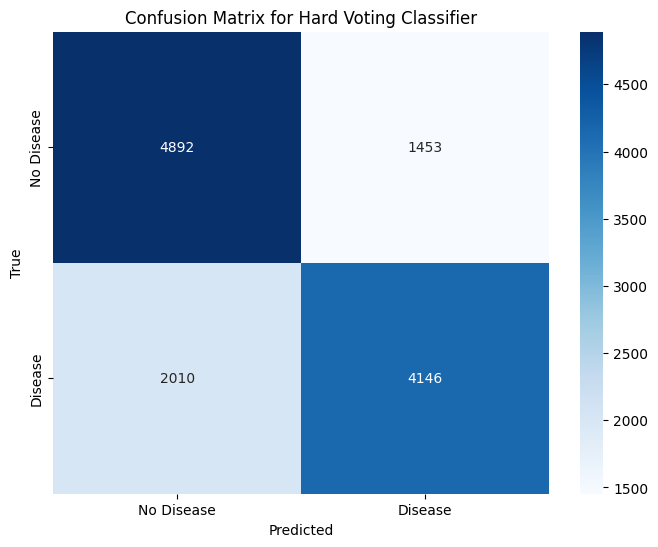

In [ ]:
cm = confusion_matrix(y_test, y_pred_evch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix for Hard Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

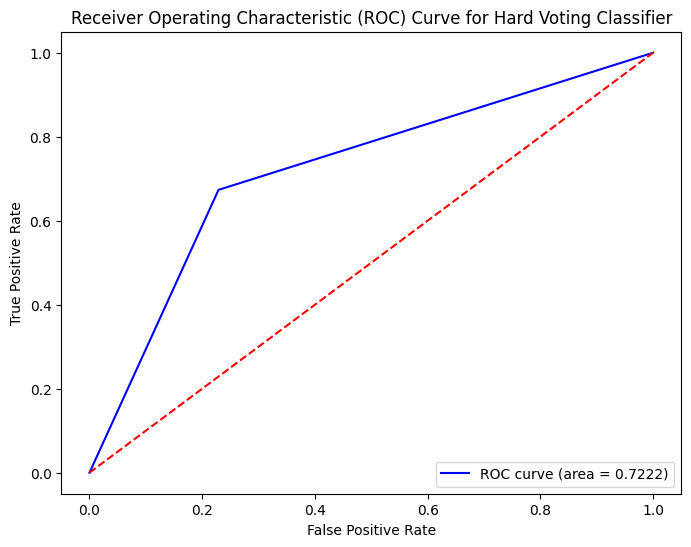

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_evch)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hard Voting Classifier')
plt.legend(loc='lower right')
plt.show()

### Soft Voting Classifier

In [ ]:
evcs = VotingClassifier(estimators=models, voting='soft')
evcs.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=np.int64(9), random_state=42,
                                                 solver='saga')),
                             ('rf',
                              RandomForestClassifier(criterion='entropy',
                                                     max_depth=np.int64(11),
                                                     min_samples_leaf=np.int64(17),
                                                     min_samples_split=np.int64(7),
                                                     n_estimators=np.int64(190),
                                                     random_state=42)),
                             ('svc',
                              SVC(C=np.float64(0.1), gamma=np.float64(0.1),
                                  probability=True)),
                             ('n...
                                            multi_strategy=None,
                                            n_estimators=np.int64(90),
                                            n_jobs=None, num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('sdg',
                              SGDClassifier(alpha=np.float64(0.0002782559402207126),
                                            eta0=np.float64(0.000774263682681127),
                                            learning_rate='constant',
                                            loss='log_loss',
                                            penalty='elasticnet')),
                             ('qda',
                              QuadraticDiscriminantAnalysis(reg_param=np.float64(0.836734693877551)))],
                 voting='soft')

In [ ]:
y_pred_evcs = evcs.predict(X_test)
accuracy_evcs = accuracy_score(y_test, y_pred_evcs)
print("Accuracy:", accuracy_evcs)
print("Precision:", precision_score(y_test, y_pred_evcs))
print("Recall:", recall_score(y_test, y_pred_evcs))
print("F1 Score:", f1_score(y_test, y_pred_evcs))
print("ROC AUC score:", roc_auc_score(y_test, y_pred_evcs))

Accuracy: 0.7216222702183825
Precision: 0.7363957597173145
Recall: 0.6770630279402209
F1 Score: 0.7054840893703453
ROC AUC score: 0.7209586219291333


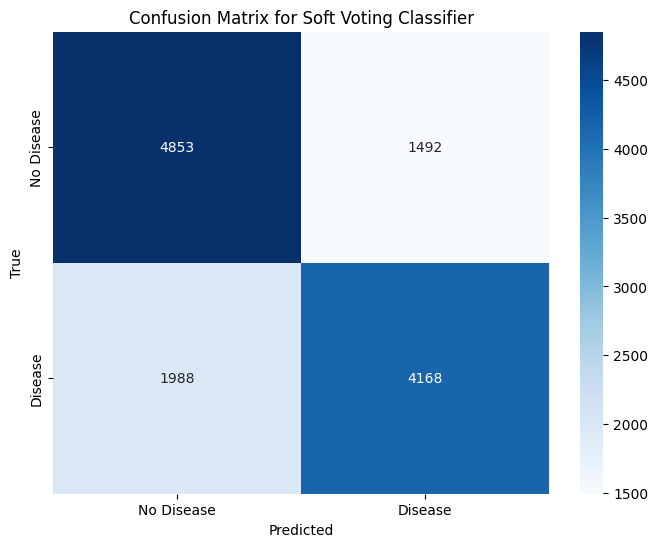

In [ ]:
cm = confusion_matrix(y_test, y_pred_evcs)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix for Soft Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

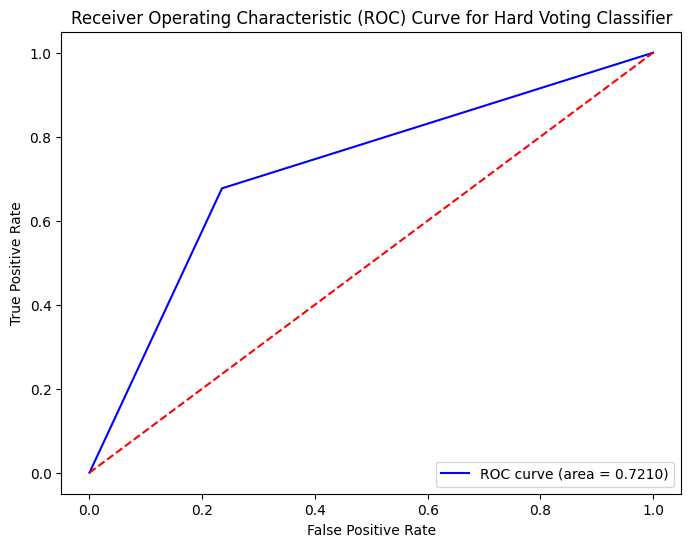

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_evcs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hard Voting Classifier')
plt.legend(loc='lower right')
plt.show()

## Models' comparison

In [ ]:
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_rf,
    'Naive Bayes': accuracy_nb,
    'KNN': accuracy_knn,
    'AdaBoost': accuracy_adb,
    'XGBoost': accuracy_xgb,
    'SGD': accuracy_sdg,
    'QDA': accuracy_qda,
    'Hard Voting': accuracy_evch,
    'Soft Voting': accuracy_evcs
}

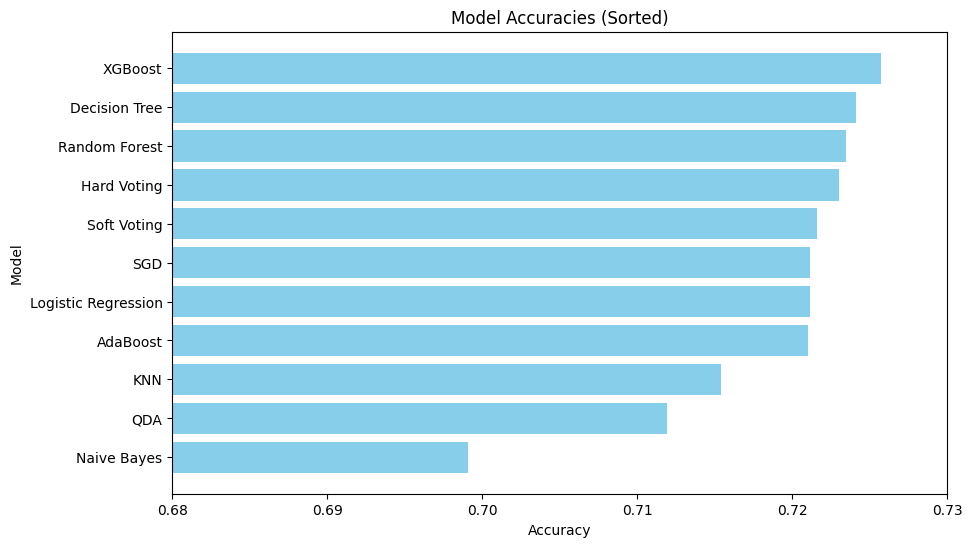

In [ ]:
sorted_accuracies = dict(sorted(accuracies.items(), key=lambda item: item[1]))
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_accuracies.keys()), list(sorted_accuracies.values()), color='skyblue')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Accuracies (Sorted)')
plt.xlim(0.68, 0.73)
plt.show()

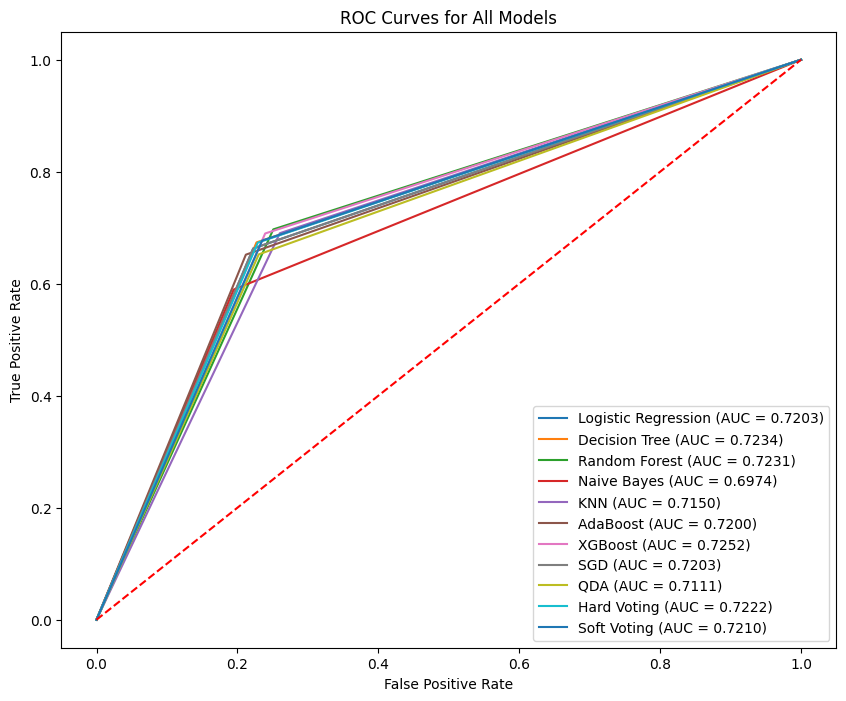

In [ ]:
plt.figure(figsize=(10, 8))

models_predictions = {
    'Logistic Regression': (best_lr, y_pred_lr),
    'Decision Tree': (best_dt, y_pred_dt),
    'Random Forest': (best_rf, y_pred_rf),
    'Naive Bayes': (best_nb, y_pred_nb),
    'KNN': (best_knn, y_pred_knn),
    'AdaBoost': (best_adb, y_pred_adb),
    'XGBoost': (best_xgb, y_pred_xgb),
    'SGD': (best_sdg, y_pred_sdg),
    'QDA': (best_qda, y_pred_qda),
    'Hard Voting': (evch, y_pred_evch),
    'Soft Voting': (evcs, y_pred_evcs)
}

for model_name, (model, y_pred) in models_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Explanation

## Shap

In [ ]:
explainer = shap.Explainer(evch.predict, X_train[:100])
shap_values = explainer(X_train[:100])

ExactExplainer explainer: 101it [1:41:59, 61.19s/it]                         


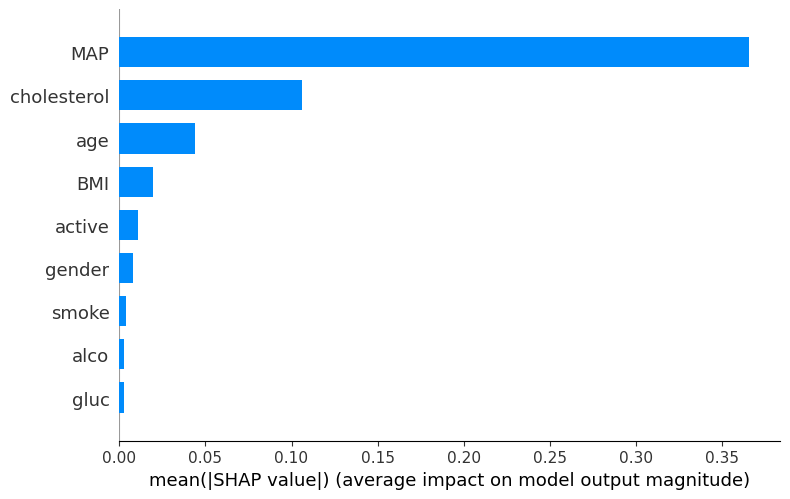

In [ ]:
shap.summary_plot(shap_values, X_train[:100], feature_names=X.columns, plot_type="bar", max_display=10)

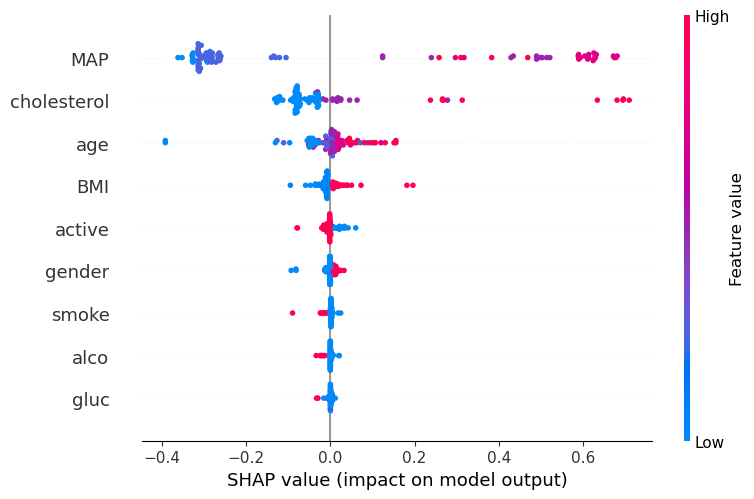

In [ ]:
shap.summary_plot(shap_values, X_train[:100], feature_names=X.columns, max_display=10)


## PFI

In [ ]:
pfi = permutation_importance(evch, X_test[:5000], y_test[:5000], n_repeats=6, random_state=42)

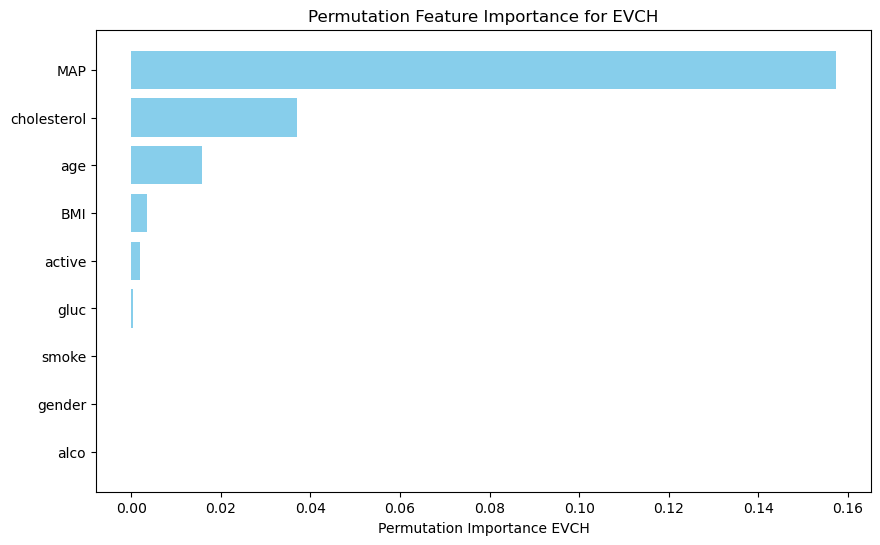

In [ ]:
sorted_idx = pfi.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], pfi.importances_mean[sorted_idx], color='skyblue')
plt.xlabel('Permutation Importance EVCH')
plt.title('Permutation Feature Importance for EVCH')
plt.show()

## Surrogate Logistic Regression Model

In [ ]:
y_evcs_proba = evcs.predict(X_train[:5000])
lreg = LogisticRegression()
lreg.fit(X_train[:5000], y_evcs_proba)

LogisticRegression()

In [ ]:
lreg.score(X_train[:5000], y_evcs_proba)

0.976

In [ ]:
feature_names = X.columns if hasattr(X, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
coefs = lreg.coef_[0]

sorted_idx = np.argsort(np.abs(coefs))[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_coefs = coefs[sorted_idx]

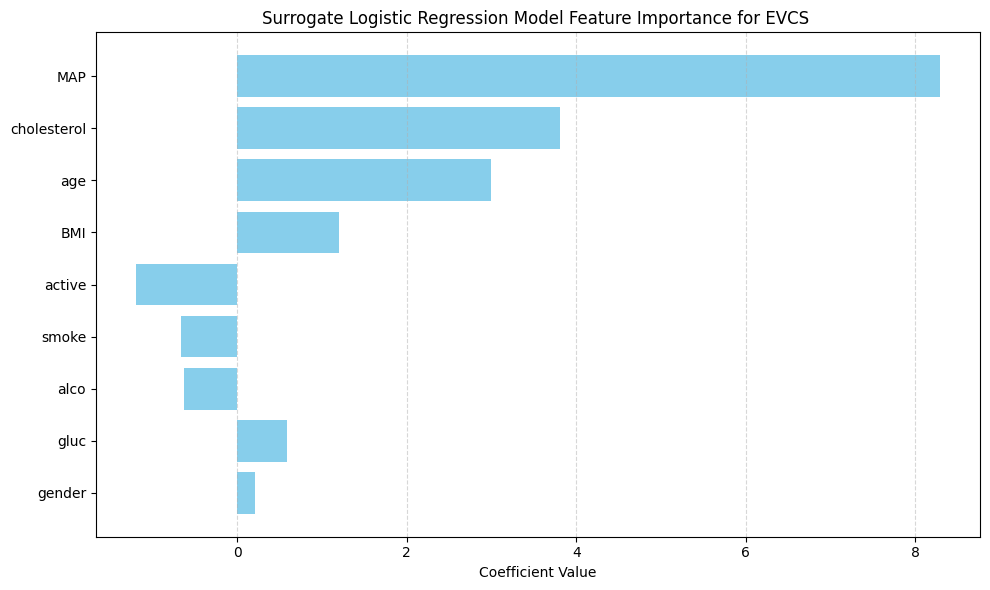

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_coefs[::-1], color='skyblue')
plt.xlabel("Coefficient Value")
plt.title("Surrogate Logistic Regression Model Feature Importance for EVCS ")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Lime

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    discretize_continuous=True
)

random_sample_index = np.random.randint(0, len(X_test))
random_sample = X_test[random_sample_index]

explanation = explainer.explain_instance(
    random_sample,
    evcs.predict_proba,
)

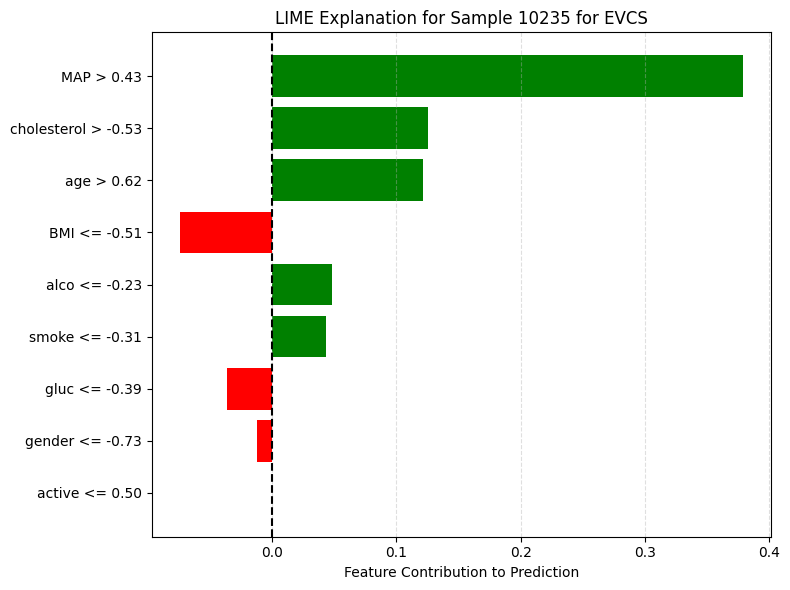

In [ ]:
exp_list = explanation.as_list(label=1)[::-1]
features = [item[0] for item in exp_list]
weights = [item[1] for item in exp_list]

plt.figure(figsize=(8, 6))
bars = plt.barh(features, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel("Feature Contribution to Prediction")
plt.title(f"LIME Explanation for Sample {random_sample_index} for EVCS", loc='center')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


## ALE

In [24]:
ale = ALE(evcs.predict_proba, feature_names=X.columns, target_names = ['No Disease', 'Disease'])
exp = ale.explain(X_test[:10000], features = [0,2,3,5,7,8])

array([[<Axes: xlabel='age', ylabel='ALE'>,
        <Axes: xlabel='cholesterol', ylabel='ALE'>,
        <Axes: xlabel='gluc', ylabel='ALE'>],
       [<Axes: xlabel='alco', ylabel='ALE'>,
        <Axes: xlabel='BMI', ylabel='ALE'>,
        <Axes: xlabel='MAP', ylabel='ALE'>]], dtype=object)

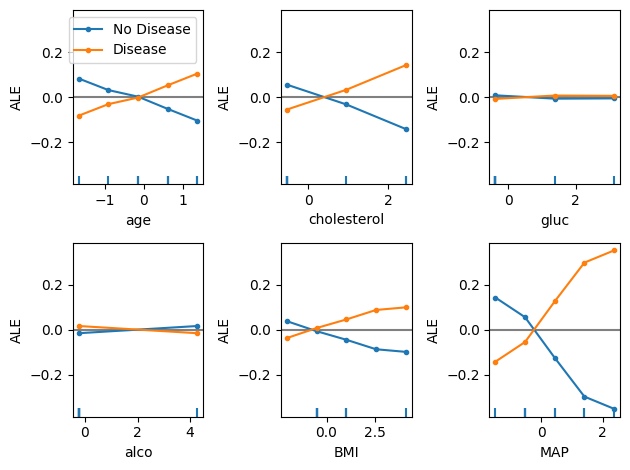

In [25]:
plot_ale(exp)